In [ ]:
import pandas as pd
import re

# Load the dataset
df = pd.read_csv("/content/Suicide_Detection.csv")

# Clean text function
def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    return text.lower().strip()

df["cleaned_text"] = df["text"].astype(str).apply(clean_text)
df["label"] = df["class"].map({"suicide": 1, "non-suicide": 0})


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train, X_test, y_train, y_test = train_test_split(
    df["cleaned_text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


              precision    recall  f1-score   support

 non-suicide       0.93      0.94      0.93     23208
     suicide       0.94      0.93      0.93     23207

    accuracy                           0.93     46415
   macro avg       0.93      0.93      0.93     46415
weighted avg       0.93      0.93      0.93     46415



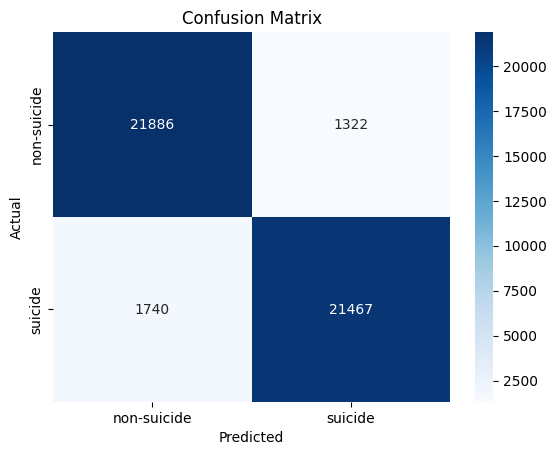

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

clf = LogisticRegression(max_iter=300)
clf.fit(X_train_tfidf, y_train)
y_pred = clf.predict(X_test_tfidf)

# Report
print(classification_report(y_test, y_pred, target_names=["non-suicide", "suicide"]))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=["non-suicide", "suicide"], yticklabels=["non-suicide", "suicide"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


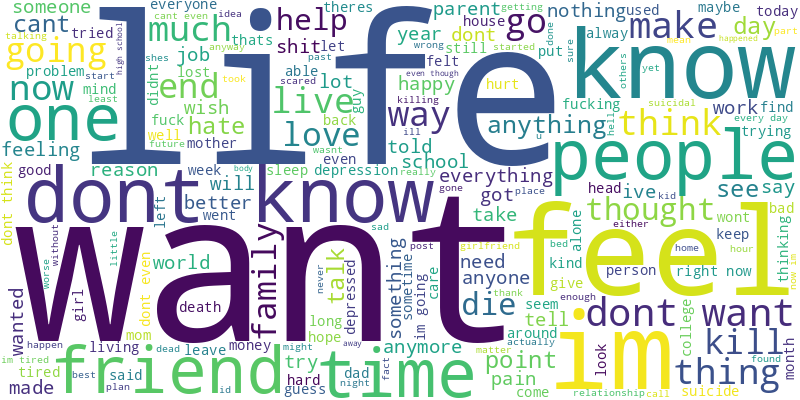

In [ ]:
from wordcloud import WordCloud

# Suicide wordcloud
wc_text = " ".join(df[df["label"] == 1]["cleaned_text"])
WordCloud(width=800, height=400, background_color="white").generate(wc_text).to_image()


In [ ]:
import numpy as np

features = np.array(vectorizer.get_feature_names_out())
weights = clf.coef_[0]
top_pos = np.argsort(weights)[-20:]
top_neg = np.argsort(weights)[:20]

print(" Suicide-related keywords:", features[top_pos][::-1])
print(" Non-suicide-related keywords:", features[top_neg])


 Suicide-related keywords: ['suicide' 'suicidal' 'kill' 'killing' 'mei' 'pills' 'mg' 'iti' 'die'
 'ending' 'life' 'helpi' 'anymorei' 'end' 'diei' 'overdose' 'rope'
 'suicidei' 'alive' 'painless']
 Non-suicide-related keywords: ['crush' 'rant' 'teenagers' 'dm' 'horny' 'minecraft' 'bruh' 'boys'
 'discord' 'filler' 'ted' 'yall' 'covid' 'award' 'cute' 'bored' 'teacher'
 'teens' 'rteenagers' 'nnn']


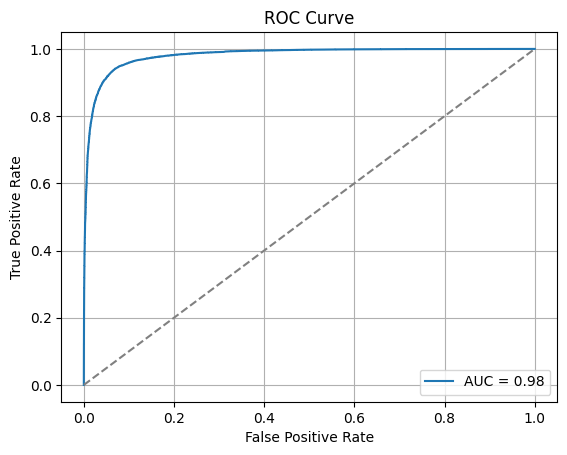

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

y_probs = clf.predict_proba(X_test_tfidf)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


In [ ]:
!pip install lime --quiet

from lime.lime_text import LimeTextExplainer

# Define a pipeline-like prediction function for LIME
class_names = ["non-suicide", "suicide"]

def predict_proba(texts):
    tfidf = vectorizer.transform(texts)
    return clf.predict_proba(tfidf)

# Create LIME explainer
explainer = LimeTextExplainer(class_names=class_names)

# Choose a sample post to explain
idx = 7  # You can change this to any index in your test set
sample_text = X_test.iloc[idx]

# Generate explanation
exp = explainer.explain_instance(sample_text, predict_proba, num_features=10)
exp.show_in_notebook(text=True)
